In [1]:
# ASSIGNMENT 3 ML Project — Preprocessing Only
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import f_classif
from scipy.stats import zscore, skew



In [2]:
har = pd.read_csv('HAR_dataset.csv')  # ensure file is alongside the notebook

print("Shape:", har.shape)
display(har.head())

assert 'target' in har.columns, "Expected a 'target' column."

Shape: (10299, 562)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V553,V554,V555,V556,V557,V558,V559,V560,V561,target
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989303,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5


In [3]:
X = har.drop(columns=['target'])
y = har['target'].astype(int)

In [4]:
print("\nX.describe():")
display(X.describe())



X.describe():


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
count,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,...,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000,10299.000000
mean,0.274347,-0.017743,-0.108925,-0.607784,-0.510191,-0.613064,-0.633593,-0.525697,-0.614989,-0.466732,...,0.126708,-0.298592,-0.617700,0.007705,0.002648,0.017683,-0.009219,-0.496522,0.063255,-0.054284
std,0.067628,0.037128,0.053033,0.438694,0.500240,0.403657,0.413333,0.484201,0.399034,0.538707,...,0.245443,0.320199,0.308796,0.336591,0.447364,0.616189,0.484770,0.511158,0.305468,0.268898
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.262624,-0.024903,-0.121019,-0.992360,-0.976990,-0.979137,-0.993294,-0.977017,-0.979064,-0.935788,...,-0.019481,-0.536174,-0.841848,-0.124694,-0.287031,-0.493108,-0.389041,-0.817287,0.002151,-0.131880
50%,0.277174,-0.017162,-0.108596,-0.943030,-0.835032,-0.850773,-0.948244,-0.843670,-0.845068,-0.874825,...,0.136245,-0.335160,-0.703402,0.008146,0.007668,0.017192,-0.007186,-0.715631,0.182028,-0.003882
75%,0.288354,-0.010625,-0.097589,-0.250293,-0.057336,-0.278737,-0.302033,-0.087404,-0.288149,-0.014641,...,0.288960,-0.113167,-0.487981,0.149006,0.291490,0.536137,0.365996,-0.521503,0.250791,0.102970
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
print("\nTarget describe():")
display(har['target'].describe())


Target describe():


count    10299.000000
mean         3.624624
std          1.743695
min          1.000000
25%          2.000000
50%          4.000000
75%          5.000000
max          6.000000
Name: target, dtype: float64

In [6]:
miss_data = X.isnull().values.any()
miss_target = pd.Series(y).isnull().values.any()

print("Is there any missing feature :", miss_data)
print("Is there any missing target  :", miss_target)

Is there any missing feature : False
Is there any missing target  : False


In [7]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))

print("IQR Outlier counts per feature (descending):")
display(outlier_mask.sum().sort_values(ascending=False).head(10))
print("Total rows that have ANY IQR outlier:", outlier_mask.any(axis=1).sum())


IQR Outlier counts per feature (descending):


V81     3871
V121    3290
V161    3148
V82     3064
V162    3048
V83     2777
V163    2736
V122    2466
V1      2437
V123    2238
dtype: int64

Total rows that have ANY IQR outlier: 9642


In [8]:
z_scores = np.abs(zscore(X, nan_policy='omit'))
outliers_z = (z_scores > 3)
print("Total rows with Z-score outlier:", outliers_z.any(axis=1).sum())

Total rows with Z-score outlier: 6481


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train class counts:\n", pd.Series(y_train).value_counts().sort_index())
print("Test  class counts:\n", pd.Series(y_test).value_counts().sort_index())

Train shape: (8239, 561) | Test shape: (2060, 561)
Train class counts:
 target
1    1378
2    1235
3    1125
4    1421
5    1525
6    1555
Name: count, dtype: int64
Test  class counts:
 target
1    344
2    309
3    281
4    356
5    381
6    389
Name: count, dtype: int64


In [10]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on TRAIN ONLY
X_test_s  = scaler.transform(X_test)        # apply to TEST

In [11]:
X_train_s = pd.DataFrame(X_train_s, columns=X_train.columns, index=X_train.index)
X_test_s  = pd.DataFrame(X_test_s,  columns=X_test.columns,  index=X_test.index)

print("Scaled train sample:")
display(X_train_s.head())

Scaled train sample:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V552,V553,V554,V555,V556,V557,V558,V559,V560,V561
10209,-0.294917,0.009693,0.107735,-0.862901,-0.955777,-0.934949,-0.853146,-0.957574,-0.940653,-0.870765,...,1.064563,0.182051,0.269242,-0.137331,0.125692,-1.067860,1.080295,1.823647,-1.847468,-1.615358
4916,0.011546,0.089392,-0.170383,-0.838996,-0.889651,-0.797144,-0.834885,-0.896904,-0.808794,-0.870763,...,-2.545894,-0.318135,-0.698069,0.430993,-0.109459,0.329916,-0.256713,-0.308684,-0.416204,-0.418366
3786,-2.224903,-3.735027,-5.535158,1.069910,1.240987,0.657414,1.138126,1.345450,0.527978,0.519201,...,1.238987,0.200872,0.046718,-0.020188,-1.774244,-1.437382,0.122113,-0.317150,0.857241,0.481775
3718,0.042866,0.016114,0.032118,-0.876694,-0.963239,-0.945608,-0.869541,-0.961667,-0.951096,-0.876513,...,-0.378312,-0.333497,-0.354407,-2.437735,-0.334052,0.399849,0.258873,2.194065,-1.633293,-1.934480
6055,0.053336,0.030672,-0.145391,-0.887439,-0.950398,-0.910850,-0.879915,-0.950139,-0.918234,-0.884354,...,1.319945,-0.483388,-0.368846,-0.107576,0.342622,1.193622,-0.511440,-0.622057,0.527277,0.326710


In [12]:
skew_value = X_train_s.apply(skew)
skewed_features = skew_value[skew_value.abs() > 1]

print("High Skewed features (|skew| > 1):")
display(skewed_features.sort_values(ascending=False))

print("Number of positively skewed features:", (skewed_features > 0).sum())
print("Number of negatively skewed features:", (skewed_features < 0).sum())


High Skewed features (|skew| > 1):


V389    14.385823
V479    13.082526
V60     13.032195
V47     11.930278
V44     11.560365
          ...    
V53     -1.628356
V41     -1.631370
V50     -1.646213
V174    -1.986610
V1      -3.673279
Length: 270, dtype: float64

Number of positively skewed features: 257
Number of negatively skewed features: 13


Class Distribution (train labels 1..6):
 target
1    1378
2    1235
3    1125
4    1421
5    1525
6    1555
Name: count, dtype: int64


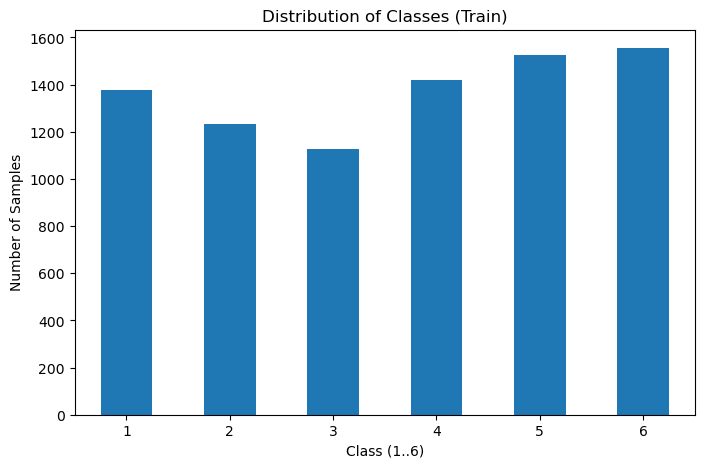

In [13]:
class_count = y_train.value_counts().sort_index()
print("Class Distribution (train labels 1..6):\n", class_count)

plt.figure(figsize=(8, 5))
class_count.plot(kind='bar')
plt.title("Distribution of Classes (Train)")
plt.xlabel("Class (1..6)")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()


In [14]:
# Use y_train as-is (1..6). Fit on TRAIN ONLY to avoid leakage.
f_val, p_val = f_classif(X_train_s, y_train)

anova_df = pd.DataFrame({
    'Feature': X_train_s.columns,
    'F_value': np.round(f_val, 2),
    'p_value': np.round(p_val, 3)
}).sort_values(by='F_value', ascending=False)

print("Top 10 features by ANOVA F (train):")
display(anova_df.head(10))


Top 10 features by ANOVA F (train):


,Feature,F_value,p_value
366,V367,40339.46,0.0
40,V41,36765.29,0.0
52,V53,35365.98,0.0
56,V57,32439.41,0.0
49,V50,32158.42,0.0
367,V368,30252.83,0.0
523,V524,25995.62,0.0
234,V235,25869.18,0.0
287,V288,25524.39,0.0
102,V103,24720.14,0.0


In [15]:
# We'll reuse these in modeling cells
vars_ready = {
    "X_train_s_shape": X_train_s.shape,
    "X_test_s_shape": X_test_s.shape,
    "y_train_minmax": (int(y_train.min()), int(y_train.max())),
    "y_test_minmax": (int(y_test.min()), int(y_test.max())),
    "n_classes": int(y_train.nunique())
}
vars_ready


{'X_train_s_shape': (8239, 561),
 'X_test_s_shape': (2060, 561),
 'y_train_minmax': (1, 6),
 'y_test_minmax': (1, 6),
 'n_classes': 6}

In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance

In [17]:
def compute_metrics(y_true, proba):
    y_pred = np.argmax(proba, axis=1) + 1  # classes will be 1..6 because y_true is 1..6
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    try:
        roc = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
    except Exception:
        roc = np.nan
    return {"accuracy": acc, "f1_macro": f1m, "roc_auc_macro": roc}

In [18]:
SEEDS = [11, 13, 17, 19, 23]
mlp_runs = []
trained_models = []

for seed in SEEDS:
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),   # ≥2 hidden layers
        activation="relu",
        solver="adam",
        learning_rate_init=1e-3,
        alpha=1e-4,
        batch_size=64,
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=seed
    )
    mlp.fit(X_train_s, y_train)
    proba = mlp.predict_proba(X_test_s)
    metrics = compute_metrics(y_test, proba)
    mlp_runs.append({"seed": seed, **metrics})
    trained_models.append(mlp)

mlp_df = pd.DataFrame(mlp_runs)
mlp_df


,seed,accuracy,f1_macro,roc_auc_macro
0,11,0.985922,0.986730,0.999501
1,13,0.982524,0.983506,0.999538
2,17,0.983010,0.983894,0.999523
3,19,0.985922,0.986614,0.999644
4,23,0.983010,0.983935,0.999349


In [19]:
means = mlp_df[["accuracy","f1_macro","roc_auc_macro"]].mean()
stds  = mlp_df[["accuracy","f1_macro","roc_auc_macro"]].std(ddof=1)

print("MLPClassifier — Results over 5 runs")
print(mlp_df)

print("\nMean ± Std")
for k in ["accuracy","f1_macro","roc_auc_macro"]:
    print(f"{k:>14}: {means[k]:.4f} ± {stds[k]:.4f}")


MLPClassifier — Results over 5 runs
   seed  accuracy  f1_macro  roc_auc_macro
0    11  0.985922  0.986730       0.999501
1    13  0.982524  0.983506       0.999538
2    17  0.983010  0.983894       0.999523
3    19  0.985922  0.986614       0.999644
4    23  0.983010  0.983935       0.999349

Mean ± Std
      accuracy: 0.9841 ± 0.0017
      f1_macro: 0.9849 ± 0.0016
 roc_auc_macro: 0.9995 ± 0.0001


In [20]:
# Choose the run with highest macro-F1
best_idx = mlp_df["f1_macro"].idxmax()
best_seed = mlp_df.loc[best_idx, "seed"]
best_model = trained_models[best_idx]

y_pred_best = best_model.predict(X_test_s)  # returns 1..6 directly
cm = confusion_matrix(y_test, y_pred_best)

print(f"Best run seed: {best_seed}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best, digits=4))


Best run seed: 11

Confusion Matrix:
 [[343   0   1   0   0   0]
 [  1 308   0   0   0   0]
 [  0   0 281   0   0   0]
 [  0   0   0 346  10   0]
 [  0   0   0  17 364   0]
 [  0   0   0   0   0 389]]

Classification Report:

              precision    recall  f1-score   support

           1     0.9971    0.9971    0.9971       344
           2     1.0000    0.9968    0.9984       309
           3     0.9965    1.0000    0.9982       281
           4     0.9532    0.9719    0.9624       356
           5     0.9733    0.9554    0.9642       381
           6     1.0000    1.0000    1.0000       389

    accuracy                         0.9859      2060
   macro avg     0.9867    0.9869    0.9867      2060
weighted avg     0.9860    0.9859    0.9859      2060



,Feature,Importance
50,V51,0.008932
53,V54,0.008107
186,V187,0.007670
41,V42,0.007427
559,V560,0.005777
185,V186,0.004660
182,V183,0.003883
145,V146,0.003835
187,V188,0.003689
142,V143,0.003495


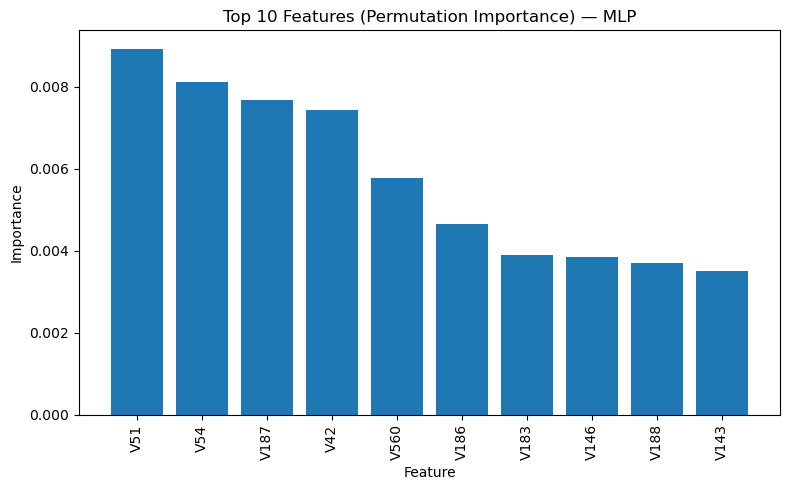

In [21]:
perm = permutation_importance(
    best_model, X_test_s, y_test,
    n_repeats=10, random_state=42, scoring="accuracy"
)

imp_df = pd.DataFrame({
    "Feature": X_test_s.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

top10 = imp_df.head(10)
display(top10)

plt.figure(figsize=(8,5))
plt.bar(top10["Feature"], top10["Importance"])
plt.title("Top 10 Features (Permutation Importance) — MLP")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)




RandomForestClassifier(min_samples_leaf=2, n_estimators=400, n_jobs=-1,
                       random_state=42)

In [23]:

# Predictions
y_proba = rf.predict_proba(X_test)           # (n_samples, 6)
y_pred  = np.argmax(y_proba, axis=1) + 1     # convert to 1..6

In [24]:
# Metrics
acc  = accuracy_score(y_test, y_pred)
f1m  = f1_score(y_test, y_pred, average="macro")
try:
    roc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
except Exception:
    roc = np.nan

print(f"Accuracy:     {acc:.4f}")
print(f"F1 (macro):   {f1m:.4f}")
print(f"ROC-AUC (OvR, macro): {roc:.4f}")

Accuracy:     0.9791
F1 (macro):   0.9790
ROC-AUC (OvR, macro): 0.9994


In [25]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))


Confusion Matrix:
 [[338   2   4   0   0   0]
 [  2 305   2   0   0   0]
 [  2   5 274   0   0   0]
 [  0   0   0 342  14   0]
 [  0   0   0  12 369   0]
 [  0   0   0   0   0 389]]

Classification Report:

              precision    recall  f1-score   support

           1     0.9883    0.9826    0.9854       344
           2     0.9776    0.9871    0.9823       309
           3     0.9786    0.9751    0.9768       281
           4     0.9661    0.9607    0.9634       356
           5     0.9634    0.9685    0.9660       381
           6     1.0000    1.0000    1.0000       389

    accuracy                         0.9791      2060
   macro avg     0.9790    0.9790    0.9790      2060
weighted avg     0.9791    0.9791    0.9791      2060



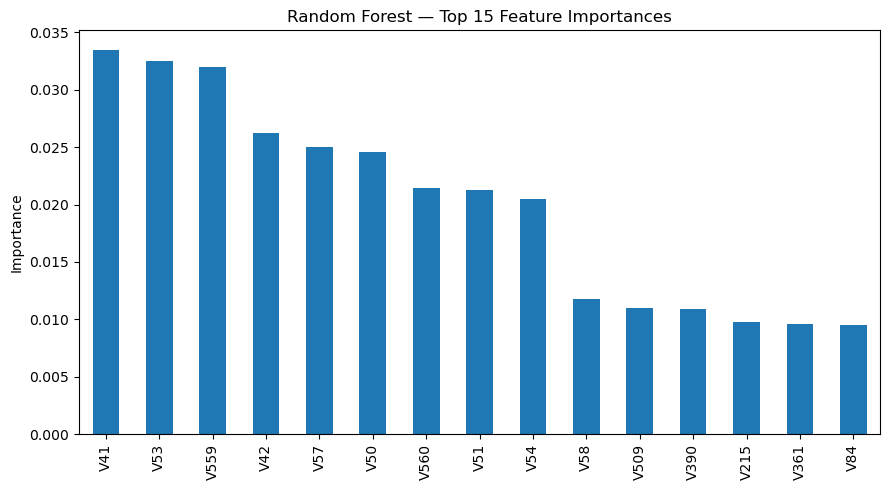

,Importance
V41,0.033502
V53,0.032488
V559,0.031949
V42,0.026199
V57,0.024992
V50,0.024617
V560,0.021431
V51,0.021305
V54,0.020514
V58,0.011801


In [26]:

imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
topk = imp.head(15)

plt.figure(figsize=(9,5))
topk.plot(kind="bar")
plt.title("Random Forest — Top 15 Feature Importances")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

topk.to_frame(name="Importance")


In [27]:
from scipy.stats import pearsonr

def metrics_from_proba(y_true, proba):
    y_pred = np.argmax(proba, axis=1) + 1  # back to labels 1..6
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    try:
        roc = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
    except Exception:
        roc = np.nan
    return acc, f1m, roc

In [28]:
corr_abs = []
for col in X_train.columns:
    c, _ = pearsonr(X_train[col], y_train)
    corr_abs.append(abs(c))

corr_series = pd.Series(corr_abs, index=X_train.columns).sort_values(ascending=False)
ranked_features = corr_series.index.tolist()

print("Top 10 features by |corr| with y (train only):")
display(corr_series.head(10).to_frame("abs_corr"))

Top 10 features by |corr| with y (train only):


,abs_corr
V105,0.858790
V103,0.858726
V104,0.854885
V368,0.854101
V235,0.848036
V367,0.846077
V185,0.844596
V289,0.843057
V524,0.830904
V369,0.830754


In [69]:
k_values = [100, 200, 300, 400, 500]
SEEDS = [42, 67, 80, 91, 100]

rows = []        # store per-k means
rows_detail = [] # optional: store each seed row

for k in k_values:
    feats_k = ranked_features[:k]
    # slice to top-k
    Xtr_k = X_train[feats_k]
    Xte_k = X_test[feats_k]

    accs, f1s, rocs = [], [], []

    for seed in SEEDS:
        # scale on TRAIN only
        scaler = StandardScaler()
        Xtr_s = scaler.fit_transform(Xtr_k)
        Xte_s = scaler.transform(Xte_k)

        mlp = MLPClassifier(
            hidden_layer_sizes=(128, 64),  # ≥2 layers
            activation="relu",
            solver="adam",
            learning_rate_init=1e-3,
            alpha=1e-4,
            batch_size=64,
            max_iter=300,
            early_stopping=True,
            n_iter_no_change=10,
            random_state=seed
        )
        mlp.fit(Xtr_s, y_train)
        proba = mlp.predict_proba(Xte_s)

        acc, f1m, roc = metrics_from_proba(y_test, proba)
        accs.append(acc); f1s.append(f1m); rocs.append(roc)

        rows_detail.append({"k": k, "seed": seed, "accuracy": acc, "f1_macro": f1m, "roc_auc_macro": roc})

    rows.append({
        "k": k,
        "accuracy_mean": np.mean(accs), "accuracy_std": np.std(accs, ddof=1),
        "f1_macro_mean": np.mean(f1s),  "f1_macro_std": np.std(f1s, ddof=1),
        "roc_auc_macro_mean": np.mean(rocs), "roc_auc_macro_std": np.std(rocs, ddof=1),
    })

df_k_summary = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
df_k_detail  = pd.DataFrame(rows_detail).sort_values(["k","seed"]).reset_index(drop=True)

print("Per-k summary (mean ± std over 5 seeds):")
display(df_k_summary)


Per-k summary (mean ± std over 5 seeds):


,k,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,roc_auc_macro_mean,roc_auc_macro_std
0,100,0.881068,0.008443,0.889015,0.008177,0.985328,0.001609
1,200,0.892718,0.005384,0.900183,0.004968,0.987704,0.000334
2,300,0.975728,0.003220,0.976907,0.003092,0.998776,0.000311
3,400,0.979806,0.000651,0.980855,0.000705,0.999208,0.000069
4,500,0.987184,0.001218,0.987782,0.001096,0.999553,0.000111


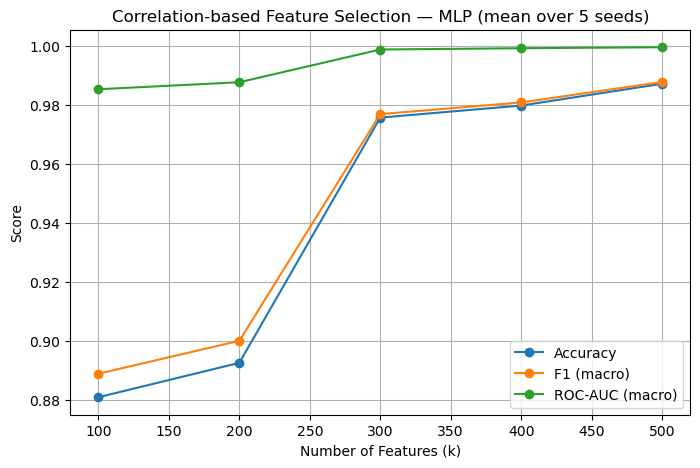

In [71]:
plt.figure(figsize=(8,5))
plt.plot(df_k_summary["k"], df_k_summary["accuracy_mean"], marker='o', label="Accuracy")
plt.plot(df_k_summary["k"], df_k_summary["f1_macro_mean"], marker='o', label="F1 (macro)")
plt.plot(df_k_summary["k"], df_k_summary["roc_auc_macro_mean"], marker='o', label="ROC-AUC (macro)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Score")
plt.title("Correlation-based Feature Selection — MLP (mean over 5 seeds)")
plt.legend()
plt.grid(True)
plt.show()


In [31]:
tbl = df_k_summary.copy()
for col in ["accuracy", "f1_macro", "roc_auc_macro"]:
    tbl[col] = (tbl[f"{col}_mean"].round(4).astype(str) + " ± " + tbl[f"{col}_std"].round(4).astype(str))
keep = ["k", "accuracy", "f1_macro", "roc_auc_macro"]
display(tbl[keep])


,k,accuracy,f1_macro,roc_auc_macro
0,100,0.8853 ± 0.0036,0.8934 ± 0.0041,0.9864 ± 0.0007
1,200,0.8972 ± 0.0113,0.9045 ± 0.0105,0.9877 ± 0.0019
2,300,0.9773 ± 0.0048,0.9784 ± 0.0047,0.999 ± 0.0001
3,400,0.9796 ± 0.0027,0.9805 ± 0.0025,0.9993 ± 0.0001
4,500,0.9844 ± 0.0012,0.985 ± 0.0012,0.9995 ± 0.0001


In [73]:
from numpy.linalg import svd

k_values = [100, 200, 300, 400, 500]
SEEDS = [42, 53, 69, 79, 91]

rows = []

for k in k_values:
    accs, f1s, rocs = [], [], []
    for seed in SEEDS:
        # Split
        Xtr, Xte, ytr, yte = train_test_split(
            X, y, test_size=0.2, random_state=seed, stratify=y
        )

        # Standardize (mean 0, variance 1)
        scaler = StandardScaler()
        Xtr_s = scaler.fit_transform(Xtr)
        Xte_s = scaler.transform(Xte)

        # --- SVD on TRAIN only ---
        # Full SVD: X = U Σ Vᵀ
        U, S, Vt = svd(Xtr_s, full_matrices=False)

        # Top-k right singular vectors (Vᵀ rows are PCs)
        Vt_k = Vt[:k, :]  # shape (k, n_features)

        # Project train/test
        Ztr = Xtr_s @ Vt_k.T
        Zte = Xte_s @ Vt_k.T

        # Train MLP
        mlp = MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu", solver="adam",
            learning_rate_init=1e-3, alpha=1e-4,
            batch_size=64, max_iter=300,
            early_stopping=True, n_iter_no_change=10,
            random_state=seed
        )
        mlp.fit(Ztr, ytr)

        # Predict & evaluate
        proba = mlp.predict_proba(Zte)
        y_pred = mlp.predict(Zte)

        accs.append(accuracy_score(yte, y_pred))
        f1s.append(f1_score(yte, y_pred, average="macro"))
        try:
            roc = roc_auc_score(yte, proba, multi_class="ovr", average="macro",
                                labels=mlp.classes_)
        except Exception:
            roc = float("nan")
        rocs.append(roc)

    rows.append({
        "k": k,
        "accuracy_mean": np.mean(accs), "accuracy_std": np.std(accs, ddof=1),
        "f1_macro_mean": np.mean(f1s),  "f1_macro_std": np.std(f1s, ddof=1),
        "roc_auc_macro_mean": np.nanmean(rocs), "roc_auc_macro_std": np.nanstd(rocs, ddof=1)
    })

# Summary table
df_svd_summary = pd.DataFrame(rows)
print("SVD Feature Reduction — mean ± std over 5 seeds")
print(df_svd_summary)



SVD Feature Reduction — mean ± std over 5 seeds
     k  accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  \
0  100       0.974660      0.005717       0.975388      0.005654   
1  200       0.983301      0.001899       0.984199      0.001832   
2  300       0.986893      0.001189       0.987493      0.001040   
3  400       0.986602      0.001266       0.987295      0.001254   
4  500       0.986311      0.001347       0.987004      0.001243   

   roc_auc_macro_mean  roc_auc_macro_std  
0            0.998941           0.000180  
1            0.999289           0.000194  
2            0.999554           0.000147  
3            0.999422           0.000264  
4            0.999541           0.000159  


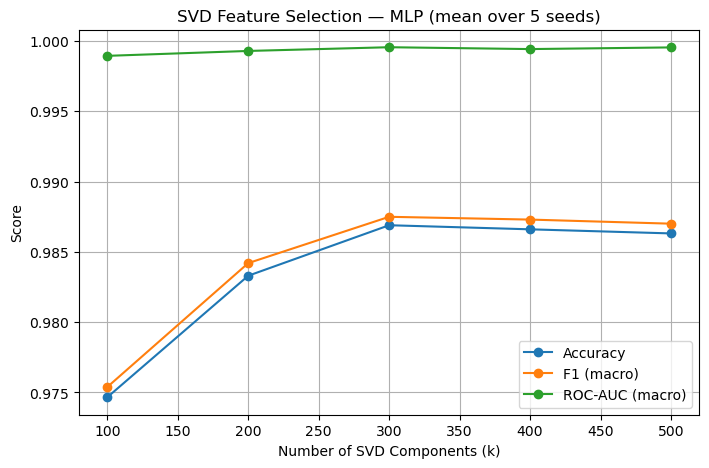

In [75]:
# Plot
plt.figure(figsize=(8,5))
plt.plot(df_svd_summary["k"], df_svd_summary["accuracy_mean"], marker='o', label="Accuracy")
plt.plot(df_svd_summary["k"], df_svd_summary["f1_macro_mean"], marker='o', label="F1 (macro)")
plt.plot(df_svd_summary["k"], df_svd_summary["roc_auc_macro_mean"], marker='o', label="ROC-AUC (macro)")
plt.xlabel("Number of SVD Components (k)")
plt.ylabel("Score")
plt.title("SVD Feature Selection — MLP (mean over 5 seeds)")
plt.legend()
plt.grid(True)
plt.show()